In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import sys
sys.path.append('/home/lokesh/OneDrive/Projects/Auditory-foraging-IRC/AF_setup_v4/irc_gym')

from irc.manager import IRCManager
from auditoryforage.utils import plot_auditory_foraging_v1_episode

# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter $lick\_cost=-3.0, food\_reward=12.0, high\_attention\_cost=-1.25$.

The following can also be done by running `demo-train.py` in command line:
```bash
python demo-train.py env_param=[-3.0,12.0,-3.0] num_epochs=20
```

No checkpoint loaded.
Initializing an agent with internal environment parameter:
(-3.0, 12.0, -1.25)
Agent evaluated for 12 episodes of length 20. Average return -68.03. (0m00.12s)

Epoch:  1/20
Agent trained by 256 time steps (0m02.32s).

Epoch:  2/20
Agent trained by 256 time steps (0m02.51s).
Agent evaluated for 12 episodes of length 20. Average return -35.27. (0m00.14s)

Epoch:  3/20
Agent trained by 256 time steps (0m02.20s).

Epoch:  4/20
Agent trained by 256 time steps (0m02.41s).
Agent evaluated for 12 episodes of length 20. Average return -5.38. (0m00.11s)

Epoch:  5/20
Agent trained by 256 time steps (0m02.08s).

Epoch:  6/20
Agent trained by 256 time steps (0m02.08s).
Agent evaluated for 12 episodes of length 20. Average return -8.65. (0m00.10s)

Epoch:  7/20
Agent trained by 256 time steps (0m01.99s).

Epoch:  8/20
Agent trained by 256 time steps (0m02.12s).
Agent evaluated for 12 episodes of length 20. Average return -1.68. (0m00.12s)

Epoch:  9/20
Agent trained by 256 tim

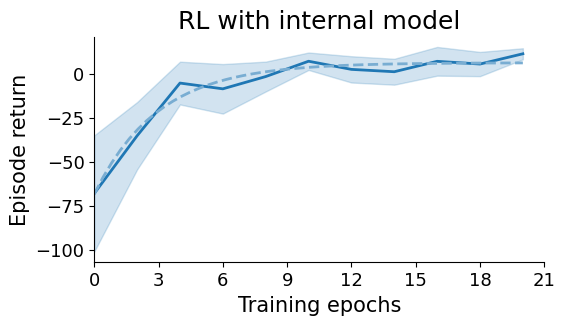

In [3]:
env_param = [-3.0, 12.0, -1.25]
num_epochs = 20

agent = manager.train_agent(env_param, num_epochs=num_epochs)
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters $(-3.0, 12.0, -1.25)$.

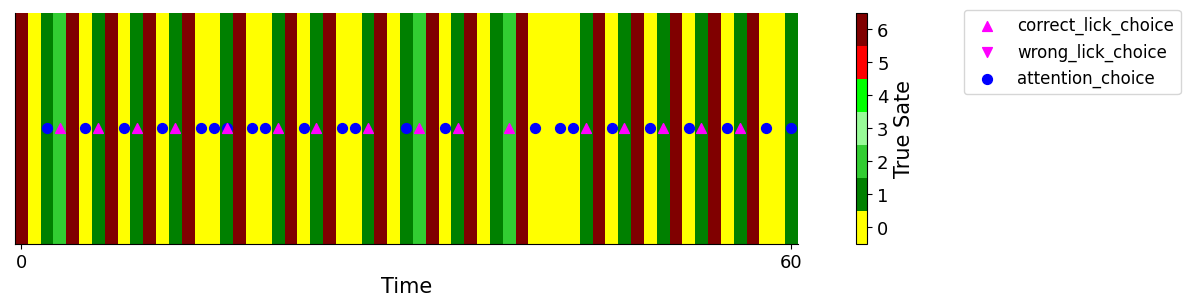

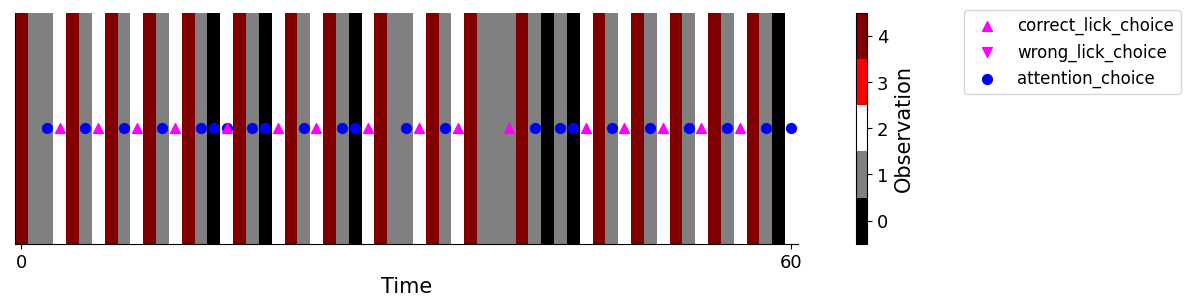

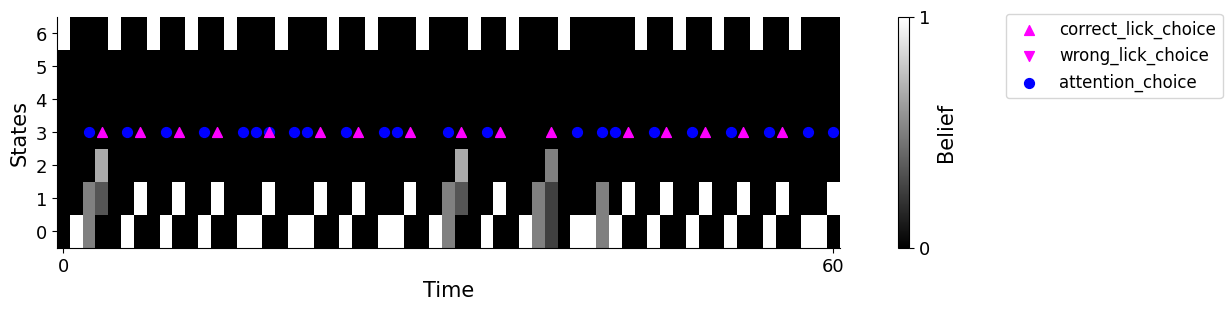

In [4]:
from auditoryforage.AF_env import AuditoryForaging

env = AuditoryForaging(spec={'experiment': {'prob_01': 0.5},'agent':{'lick_cost':-3,'food_reward':12,'high_attention_cost':-1.25}})
env.spec

episode = agent.run_one_episode(env=env, num_steps=60, q_states = [[i] for i in range(7)])
fig = plot_auditory_foraging_v1_episode(episode)

We can save the episode data in an external `pickle` file.

In [5]:
import os, pickle

episode_path = 'store/episode_00.pickle'

if os.path.exists(episode_path):
    print(f"File {episode_path} already exists, will not be overwritten.")
else:
    with open(episode_path, 'wb') as f:
        pickle.dump({
            'external_env_param': env.get_param(),
            'internal_env_param': agent.model.env.get_param(),
            **episode,
        }, f)
    print(f"Episode data saved at '{episode_path}'.")

Episode data saved at 'store/episode_00.pickle'.


## Sanity check

We show that belief updates done using anayltical update (from environemt file) is the same as what we get using sampling approach (previous plot).

In [6]:
# actions = episode["actions"]
# observations = episode["observations"]
# offset_actions = np.insert(actions, -1, 0, axis=0) #offset actions to match time steps, as the action at last time step is not taken.
# previous_belief = 1/7 * np.ones((7,1))
# computed_beliefs = []
# for ind in range(len(offset_actions)):
#     try:
#         next_belief = env.update_belief(previous_belief, observations[ind][0], offset_actions[ind-1])
#     except:
#         next_belief = env.update_belief(previous_belief, observations[ind][0], 0)
#     computed_beliefs.append(next_belief)
#     previous_belief = next_belief
# episode["q_probs"] = np.array(computed_beliefs)
# fig = plot_auditory_foraging_v1_episode(episode)

# Train multiple agents for different environments

## Sweep over parameter grid

We define a grid of environment parameters, and train multiple agents for each of the combination using different random seeds.

The following can also be done by running `demo-sweep.py` in command line:
```bash
python demo-sweep.py env_param_grid=param_grids/param_grid_0.yaml num_epochs=20 count=5
```

In [7]:
# Lokesh changed to smaller search space.

env_param_grid = [
    [-1.0, -3.0, -5.0, -50.0], # lick_cost
    [1.0, 8.0, 12.0, 50.0], # food_reward
    [-.95, -1.1, -1.25, -1.4], # high_attention_cost
]

num_epochs = 20 # number of RL epochs

# manager.train_agents(env_param_grid=env_param_grid, num_epochs=num_epochs, count=count)
manager.train_agents(env_param_grid=env_param_grid, num_epochs=num_epochs)

Use default agent seeds [0, 1, 2] for each environment parameter.
------------
Processing E7E9B3CC (1)...
No checkpoint loaded.
Initializing an agent with internal environment parameter:
(-5.0, 1.0, -0.95)
Agent evaluated for 12 episodes of length 20. Average return -100.21. (0m00.13s)

Epoch:  1/20
Agent trained by 256 time steps (0m01.96s).

Epoch:  2/20
Agent trained by 256 time steps (0m01.97s).
Agent evaluated for 12 episodes of length 20. Average return -67.27. (0m00.11s)

Epoch:  3/20
Agent trained by 256 time steps (0m01.99s).

Epoch:  4/20
Agent trained by 256 time steps (0m02.07s).
Agent evaluated for 12 episodes of length 20. Average return -42.23. (0m00.10s)

Epoch:  5/20
Agent trained by 256 time steps (0m02.01s).

Epoch:  6/20
Agent trained by 256 time steps (0m02.01s).
Agent evaluated for 12 episodes of length 20. Average return -30.62. (0m00.10s)

Epoch:  7/20
Agent trained by 256 time steps (0m01.97s).

Epoch:  8/20
Agent trained by 256 time steps (0m02.05s).
Agent eva

In [8]:
report = manager.overview_agents(env_param_grid=env_param_grid)

Use default agent seeds [0, 1, 2] for each environment parameter.
Average number of trained epochs: 20.0
Approximate training time 0m02.04s per epoch.
Approximate evaluation time 0m00.10s.
Average training optimality 98.5%


# Compute likelihood of an episode

## Likelihood of a specific agent

Given a sequence actions and observations, we compute the likelihood of episode data conditioned on a trained agent $p(a_{1:t}, o_{1:t}|\theta_\mathrm{agent})$.

In [9]:
logp = agent.episode_likelihood(episode['actions'], episode['observations'])
print('log likelihood {:.3f}'.format(logp))

log likelihood -20.733


## Likelihood of a series of agents

After multiple agents have been trained on a grid of environment parameters, compute the likelihood of episode data conditioned on each agent.

In [33]:
from irc.utils import logmeanexp

episode_path = 'episode_00.pickle'

env_param_grid = [
    [-1.0, -3.0, -5.0, -50.0], # lick_cost
    [1.0, 8.0, 12.0, 50.0], # food_reward
    [-.95, -1.1, -1.25, -1.4], # high_attention_cost
]

logps = manager.compute_logps(episode_path=episode_path, env_param_grid=env_param_grid, min_epoch=5, min_optimality=.9)

# logps = logmeanexp(logps, axis=(-2, -1))
# print(f"Log likelihood of all environments saved in an array of shape {logps.shape}")

p = np.exp(logmeanexp(logps, axis=(-2, -1)))
p /= np.nansum(p)

print(f"Probabilities of all environments saved in an array of shape {p.shape}")

Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
188 valid agents found.
Computing likelihood of episode 825D81 (60 time steps)...
0 works processed.
All works are processed or being processed.
97.92% of the likelihood entries have been computed.
Probabilities of all environments saved in an array of shape (4, 4, 4)


In [34]:
p

array([[[7.66800442e-150, 6.04363230e-171, 1.63830475e-167,
         3.23292286e-161],
        [3.53063457e-008, 2.82548292e-010, 1.04869039e-020,
         2.96292318e-023],
        [8.49494929e-003, 1.48156188e-001, 2.03857560e-001,
         6.20542033e-002],
        [6.64202702e-014, 6.65550538e-013, 5.57729388e-014,
         1.20405530e-014]],

       [[4.01552933e-147, 3.33120380e-167, 1.50813231e-167,
         2.39321274e-169],
        [1.37203309e-031, 3.20891547e-048, 7.71218825e-048,
         1.71513637e-046],
        [3.98315543e-001, 3.49037459e-002, 1.20465697e-001,
         2.37520778e-002],
        [6.91977465e-013, 5.81454065e-013, 8.18766736e-011,
         2.83267539e-011]],

       [[1.45841656e-138, 1.07822695e-145, 2.99225480e-152,
         2.59082830e-163],
        [2.75787376e-053, 6.06127608e-054, 9.87708195e-060,
         2.05205153e-064],
        [4.47555151e-013, 8.95162657e-029, 5.85727078e-028,
         1.92707070e-026],
        [9.45633241e-011, 2.40205334e-0

In [11]:
# from irc.utils import logmeanexp

# # for episode_path in ['episode_{:02d}.pickle'.format(i) for i in range(4, 12)]:
# for episode_path in ['episode_00.pickle']:
#     with open(f'store/{episode_path}', 'rb') as f:
#         saved = pickle.load(f)
#     print('External environment parameter: {}'.format(tuple(saved['external_env_param'])))
#     print('Length of episode: {}'.format(saved['num_steps']))
    
#     logps = manager.compute_logps(
#         episode_path=episode_path, env_param_grid=env_param_grid,
#         agent_seeds=agent_seeds, min_epoch=25, min_optimality=0.98, patience=0,
#     )

#     p = np.exp(logmeanexp(logps, axis=(-2, -1)))
#     p /= np.nansum(p)

#     _, axes = plt.subplots(1, p.shape[2], figsize=(8, 2.5), gridspec_kw={'wspace': 0.02})
#     for i, ax in enumerate(axes):
#         h = ax.imshow(p[..., i], vmin=0, vmax=np.nanmax(p))
#         ax.set_title(r'$r_\mathrm{food}$'+'={:g}'.format(env_param_grid[2][i]))
#         ax.set_xticks(range(p.shape[1]))
#         ax.set_xticklabels(['{:g}'.format(v) for v in env_param_grid[1]])
#         ax.set_xlabel(r'$p_\mathrm{cue}$')
#         ax.set_yticks(range(p.shape[0]))
#         if i==0:
#             ax.set_yticklabels(['{:g}'.format(v) for v in env_param_grid[0]])
#             ax.set_ylabel(r'$p_\mathrm{appear}$')
#         else:
#             ax.set_yticklabels([])
#     # agent environment parameter
#     with open(f'store/{episode_path}', 'rb') as f:
#         saved = pickle.load(f)
#     env_param = saved['internal_env_param']
#     i = env_param_grid[0].index(env_param[0])
#     j = env_param_grid[1].index(env_param[1])
#     k = env_param_grid[2].index(env_param[2])
#     axes[k].scatter(j, i, s=30, marker='o', color='tomato')
#     env_param = saved['external_env_param']
#     i = env_param_grid[0].index(env_param[0])
#     j = env_param_grid[1].index(env_param[1])
#     k = env_param_grid[2].index(env_param[2])
#     axes[k].scatter(j, i, s=40, marker='s', edgecolor='orchid', facecolor='none', linewidth=2)
#     plt.colorbar(h, ax=axes, label=r'$p(\theta|a_{1:t},o_{1:t})$', fraction=0.1)
#     plt.show()

In [32]:
print(p)

[[[1.29994718e-149 1.02456941e-170]
  [5.98544053e-008 4.79000578e-010]
  [1.44013811e-002 2.51167328e-001]]

 [[6.80747654e-147 5.64734804e-167]
  [2.32599049e-031 5.44003418e-048]
  [6.75259348e-001 5.91718829e-002]]

 [[2.47243531e-138 1.82790464e-145]
  [4.67538882e-053 1.02756054e-053]
  [7.58734637e-013 1.51755803e-028]]

 [[5.05975010e-091 6.06136874e-098]
  [1.61401088e-098 1.48444602e-098]
  [1.41479621e-098 9.11846919e-102]]]
